#### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#### Dataset






In [2]:
df = pd.read_csv("gold_data.csv")

In [ ]:
df.head()

,Date,Gold_Open,Gold_High,Gold_Low,Gold_Close,Gold_Volume,DXY,SP500,Oil,VIX,...,Daily_Return,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,Target
0,2000-10-18,270.299988,270.299988,270.299988,270.299988,0.0,117.330002,1342.130005,33.549999,28.719999,...,-0.002951,44.027677,-0.811933,-0.890278,0.078346,277.007532,272.364998,267.722464,1.797421,270.100006
1,2000-10-19,270.100006,270.100006,270.100006,270.100006,1.0,116.940002,1388.760010,32.950001,25.090000,...,-0.000740,43.589968,-0.887787,-0.889780,0.001993,277.016104,272.354999,267.693893,1.683319,271.200012
2,2000-10-20,271.200012,271.200012,271.200012,271.200012,32.0,117.160004,1396.930054,34.299999,24.240000,...,0.004073,46.727258,-0.849350,-0.881694,0.032344,277.007681,272.325000,267.642319,1.641653,270.100006
3,2000-10-23,271.700012,271.700012,270.100006,270.100006,1.0,117.540001,1395.780029,33.730000,24.690001,...,-0.004056,44.086729,-0.897306,-0.884817,-0.012490,276.828986,272.125000,267.421014,1.638679,270.100006
4,2000-10-24,269.799988,270.100006,269.799988,270.100006,16.0,117.419998,1398.130005,33.369999,24.280001,...,0.000000,44.086729,-0.924653,-0.892784,-0.031869,276.643831,271.935001,267.226170,1.543060,266.200012


In [ ]:
df.shape

(6468, 24)

In [ ]:
print("Number of Columns:", df.shape[1])
print("Number of Rows:", df.shape[0])

Number of Columns: 24
Number of Rows: 6468


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6468 entries, 2000-10-18 to 2026-07-30
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Gold_Open     6468 non-null   float64
 1   Gold_High     6468 non-null   float64
 2   Gold_Low      6468 non-null   float64
 3   Gold_Close    6468 non-null   float64
 4   Gold_Volume   6468 non-null   float64
 5   DXY           6468 non-null   float64
 6   SP500         6468 non-null   float64
 7   Oil           6468 non-null   float64
 8   VIX           6468 non-null   float64
 9   Lag1          6468 non-null   float64
 10  Lag7          6468 non-null   float64
 11  MA7           6468 non-null   float64
 12  MA30          6468 non-null   float64
 13  EMA20         6468 non-null   float64
 14  Daily_Return  6468 non-null   float64
 15  RSI           6468 non-null   float64
 16  MACD          6468 non-null   float64
 17  MACD_Signal   6468 non-null   float64
 18  MACD_Hist 

In [ ]:
df.describe()

,Gold_Open,Gold_High,Gold_Low,Gold_Close,Gold_Volume,DXY,SP500,Oil,VIX,Lag1,...,Daily_Return,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,Target
count,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,...,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000
mean,1331.326408,1338.590121,1323.732607,1331.278663,4289.251237,92.508420,2405.750051,65.248230,19.743652,1330.686672,...,0.000484,52.922866,4.177401,4.209752,-0.032351,1374.027614,1325.715645,1277.403675,17.656730,1331.862893
std,874.129231,880.732577,866.927261,873.866684,23983.824104,11.006872,1619.893786,24.513317,8.392199,873.287451,...,0.011262,12.197426,21.995293,20.787465,6.302385,909.924973,867.760295,826.979542,18.848183,874.420246
min,255.000000,256.100006,255.000000,255.100006,0.000000,71.330002,676.530029,-37.630001,9.140000,255.100006,...,-0.113662,16.555742,-152.862263,-115.158309,-95.153851,262.690584,259.269998,252.954794,0.858960,255.100006
25%,662.500000,665.200012,660.724991,662.500000,24.000000,82.599998,1209.544952,47.097499,13.970000,662.449997,...,-0.004845,44.500461,-4.174402,-3.937399,-2.144649,684.193391,662.072501,639.583150,7.429916,662.574982
50%,1258.549988,1265.600037,1253.450012,1258.400024,121.000000,93.235001,1693.320007,64.455002,17.585000,1258.250000,...,0.000519,52.434576,1.816377,1.732898,0.141395,1296.852761,1260.665005,1218.915205,14.667469,1258.599976
75%,1719.375031,1728.325043,1708.950012,1719.925049,467.000000,99.512501,3087.815002,82.699997,23.012500,1719.649994,...,0.006401,61.602148,11.067144,10.772167,2.370561,1777.566373,1719.417505,1662.596157,20.780509,1720.325043
max,5415.700195,5586.200195,5301.600098,5318.399902,386334.000000,120.900002,7609.779785,145.289993,82.690002,5318.399902,...,0.090277,87.904154,227.374043,170.076845,62.694653,5530.114159,5119.044971,4941.546783,200.652560,5318.399902


#### Data Preprocessing

In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

In [4]:
y = df['Target']
#X = df.drop(columns=['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Volume', 'ATR', 'Target'])
X = df[[
    'Lag1',
    'Lag7',
    'MA7',
    'MA30',
    'EMA20'
]]

In [5]:
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

In [6]:
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

In [7]:
time_step = 30

X_seq = []
y_seq = []

for i in range(time_step, len(X_scaled)):
    X_seq.append(X_scaled[i-time_step:i])
    y_seq.append(y_scaled[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

In [8]:
print(X_seq.shape)
print(y_seq.shape)

(6438, 30, 5)
(6438, 1)


In [9]:
train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
X_test = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test = y_seq[train_size:]

In [10]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5150, 30, 5)
X_test : (1288, 30, 5)
y_train: (5150, 1)
y_test : (1288, 1)


#### Model Architecture

In [11]:
model = Sequential()

model.add(LSTM(units=128,return_sequences=True,input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### Model Training

In [12]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - loss: 7.5163e-04 - mae: 0.0163 - val_loss: 0.0021 - val_mae: 0.0287
Epoch 2/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - loss: 2.3447e-04 - mae: 0.0109 - val_loss: 0.0018 - val_mae: 0.0269
Epoch 3/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - loss: 2.0392e-04 - mae: 0.0100 - val_loss: 0.0014 - val_mae: 0.0239
Epoch 4/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - loss: 1.9039e-04 - mae: 0.0097 - val_loss: 5.5056e-04 - val_mae: 0.0161
Epoch 5/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - loss: 1.7718e-04 - mae: 0.0093 - val_loss: 0.0012 - val_mae: 0.0226
Epoch 6/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 1.5669e-04 - mae: 0.0088 - val_loss: 0.0015 - val_mae: 0.0261
Epoch 7/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 1.4802e-04 - mae: 0.0087 - val_loss: 6.1401e-04 - val_mae: 0.0157
Epoch 8/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 1.2900e-04 - mae: 0.0082 - val_loss: 5.0888e-04 - val_mae: 0.01

#### Model Evaluation

In [14]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss (MSE): {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")

Test Loss (MSE): 0.000226
Test MAE: 0.009638


In [15]:
y_pred = model.predict(X_test)

y_test_actual = scaler_y.inverse_transform(y_test)
y_pred_actual = scaler_y.inverse_transform(y_pred)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [16]:
mae_scaled = mean_absolute_error(y_test, y_pred)
mse_scaled = mean_squared_error(y_test, y_pred)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred)

print(f"MAE  : {mae_scaled:.6f}")
print(f"MSE  : {mse_scaled:.6f}")
print(f"RMSE : {rmse_scaled:.6f}")
print(f"R²   : {r2_scaled:.4f}")

MAE  : 0.009638
MSE  : 0.000226
RMSE : 0.015047
R²   : 0.9939


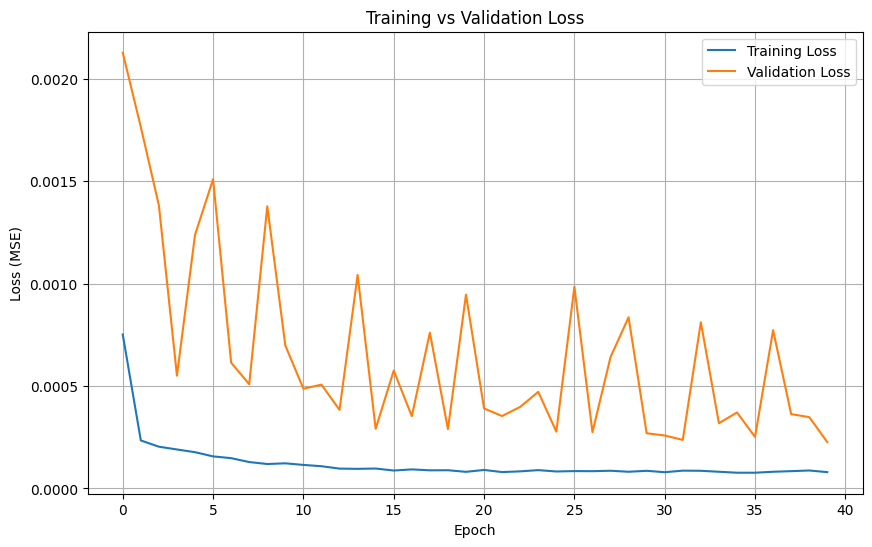

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.show()